In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('TensorFlow:', tf.__version__)

DRIVE    = '/content/drive/MyDrive'
DATA_DIR = f'{DRIVE}/Colab_Notebooks/ECO_Dataset/eco_processed'
DEC_DIR  = f'{DRIVE}/eco_decomposed'
OUT_DIR  = f'{DRIVE}/phase2_outputs'

import os
os.makedirs(OUT_DIR, exist_ok=True)

# Load Phase 1 artefacts,
base_profiles = pd.read_csv(f'{DEC_DIR}/base_profiles.csv', index_col=0)
delta_table   = pd.read_csv(f'{DEC_DIR}/cross_house_delta_table.csv')

print('Base profiles shape :', base_profiles.shape)
print('Delta table shape   :', delta_table.shape)
print('\\nBase profiles (mean W by hour):')
print(base_profiles.describe().round(1))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
Base profiles shape : (24, 3)
Delta table shape   : (48, 5)
\nBase profiles (mean W by hour):
       house_01  house_02  house_04
count      24.0      24.0      24.0
mean      284.7     210.1     887.7
std       124.1      99.7     596.3
min        97.9      87.9     499.3
25%       196.3     119.0     676.2
50%       295.0     192.6     701.2
75%       335.9     274.2     846.8
max       542.1     387.5    3199.0


# Load and Merge ECO Houses

In [ ]:
def load_and_resample(house_id, freq='1h'):
    """
    Load 1-min ECO data, resample to hourly for LSTM.
    Hourly is better for 24h-ahead forecasting — less noise,
    more stable patterns, faster training.
    """
    df = pd.read_csv(
        f'{DATA_DIR}/house_{house_id}_1min.csv',
        index_col=0, parse_dates=True
    )
    hourly = df.resample(freq).agg({
        'power_W':  'mean',
        'occupied': 'mean'   # fraction of hour occupied
    }).dropna()
    hourly['house']      = house_id
    hourly['hour']       = hourly.index.hour
    hourly['dayofweek']  = hourly.index.dayofweek
    hourly['month']      = hourly.index.month
    hourly['is_weekend'] = (hourly.index.dayofweek >= 5).astype(int)
    hourly['day_sin']    = np.sin(2 * np.pi * hourly.index.hour / 24)
    hourly['day_cos']    = np.cos(2 * np.pi * hourly.index.hour / 24)
    hourly['week_sin']   = np.sin(2 * np.pi * hourly.index.dayofweek / 7)
    hourly['week_cos']   = np.cos(2 * np.pi * hourly.index.dayofweek / 7)
    hourly['month_sin']  = np.sin(2 * np.pi * hourly.index.month / 12)
    hourly['month_cos']  = np.cos(2 * np.pi * hourly.index.month / 12)
    print(f'House {house_id}: {len(hourly):,} hourly rows | \
          {hourly.index.min().date()} → {hourly.index.max().date()}')
    return hourly


h01 = load_and_resample('01')
h02 = load_and_resample('02')

# Combine for multi-house training (more data = better generalisation)
combined = pd.concat([h01, h02]).sort_index()
print(f'\nCombined: {len(combined):,} rows')

House 01: 4,296 hourly rows |           2012-07-15 → 2013-01-09
House 02: 5,472 hourly rows |           2012-06-01 → 2013-01-15

Combined: 9,768 rows


# Feature Engineering

In [ ]:
def add_lag_features(df, lags=[1, 2, 3, 6, 12, 24, 48, 168]):
    """
    Add lagged power features:
    - 1,2,3h: short-term autocorrelation
    - 6,12h: within-day patterns
    - 24h: same hour yesterday
    - 48h: 2 days ago
    - 168h: same hour last week
    """
    for lag in lags:
        df[f'lag_{lag}h'] = df.groupby('house')['power_W'].shift(lag)

    # Rolling statistics
    for window in [6, 24]:
        df[f'roll_mean_{window}h'] = (
            df.groupby('house')['power_W']
            .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )
        df[f'roll_std_{window}h'] = (
            df.groupby('house')['power_W']
            .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
        )

    # Daily energy so far (cumulative within day)
    df['daily_energy_so_far'] = (
        df.groupby([df.index.date, 'house'])['power_W']
        .transform(lambda x: x.shift(1).cumsum().fillna(0))
    )
    return df


# Apply to each house separately (lag features must not bleed across houses)
h01_feat = add_lag_features(h01.copy())
h02_feat = add_lag_features(h02.copy())

# Re-combine after feature engineering
data = pd.concat([h01_feat, h02_feat]).sort_index().dropna()

feature_cols = [
    'day_sin', 'day_cos', 'week_sin', 'week_cos',
    'month_sin', 'month_cos', 'is_weekend', 'occupied',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h',
    'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h',
    'roll_mean_6h', 'roll_std_6h',
    'roll_mean_24h', 'roll_std_24h',
    'daily_energy_so_far',
]
target_col = 'power_W'

print(f'Features: {len(feature_cols)}')
print(f'Dataset rows after dropna: {len(data):,}')
print(feature_cols)

Features: 21
Dataset rows after dropna: 9,432
['day_sin', 'day_cos', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'is_weekend', 'occupied', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_24h', 'roll_std_24h', 'daily_energy_so_far']


# Train / Validation / Test Split + Normalisation

In [ ]:
# Time-based split — no data leakage
# Use H02 only for final test (held-out house strategy)
train_data = data[data['house'] == '01'].copy()
test_data  = data[data['house'] == '02'].copy()

# Within H01: last 20% as validation
n_train = int(len(train_data) * 0.8)
val_data = train_data.iloc[n_train:].copy()
train_data = train_data.iloc[:n_train].copy()

print(f'Train (H01 80%): {len(train_data):,} rows | \
      {train_data.index.min().date()} → {train_data.index.max().date()}')
print(f'Val   (H01 20%): {len(val_data):,} rows  | \
      {val_data.index.min().date()} → {val_data.index.max().date()}')
print(f'Test  (H02    ): {len(test_data):,} rows  | \
      {test_data.index.min().date()} → {test_data.index.max().date()}')

# Normalise using TRAIN statistics only
feat_scaler   = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train = feat_scaler.fit_transform(train_data[feature_cols])
y_train = target_scaler.fit_transform(train_data[[target_col]])

X_val   = feat_scaler.transform(val_data[feature_cols])
y_val   = target_scaler.transform(val_data[[target_col]])

X_test  = feat_scaler.transform(test_data[feature_cols])
y_test  = target_scaler.transform(test_data[[target_col]])

print(f'\nTarget scaler range: [{target_scaler.data_min_[0]:.1f}, \
      {target_scaler.data_max_[0]:.1f}] W')

Train (H01 80%): 3,302 rows |       2012-07-22 → 2012-12-06
Val   (H01 20%): 826 rows  |       2012-12-06 → 2013-01-09
Test  (H02    ): 5,304 rows  |       2012-06-08 → 2013-01-15

Target scaler range: [0.0,       2391.6] W


# 4. Sliding Window - Seq 2 Seq format for 24 hours

In [ ]:
LOOKBACK  = 168   # 7 days of hourly data as context
HORIZON   = 24    # predict next 24 hours

def make_sequences(X, y, lookback=168, horizon=24):
    """
    Encoder-decoder format:
      X_enc : (samples, lookback, features)  ← past 7 days
      X_dec : (samples, horizon, features)   ← known future features
                                               (calendar only, no power)
      y_out : (samples, horizon, 1)          ← 24h target
    """
    # Calendar-only features for decoder (cols 0-6: sin/cos + is_weekend + occupied)
    calendar_idx = list(range(8))   # day_sin, day_cos, week_sin, week_cos,
                                    # month_sin, month_cos, is_weekend, occupied
    X_enc_list, X_dec_list, y_list = [], [], []

    total = len(X) - lookback - horizon + 1
    for i in range(total):
        enc_end = i + lookback
        dec_end = enc_end + horizon
        X_enc_list.append(X[i:enc_end])
        X_dec_list.append(X[enc_end:dec_end, :len(calendar_idx)])
        y_list.append(y[enc_end:dec_end])

    return (np.array(X_enc_list, dtype=np.float32),
            np.array(X_dec_list, dtype=np.float32),
            np.array(y_list,     dtype=np.float32))


print('Building sequences...')
Xe_tr, Xd_tr, y_tr = make_sequences(X_train, y_train, LOOKBACK, HORIZON)
Xe_va, Xd_va, y_va = make_sequences(X_val,   y_val,   LOOKBACK, HORIZON)
Xe_te, Xd_te, y_te = make_sequences(X_test,  y_test,  LOOKBACK, HORIZON)

print(f'Train: enc={Xe_tr.shape}  dec={Xd_tr.shape}  y={y_tr.shape}')
print(f'Val  : enc={Xe_va.shape}  dec={Xd_va.shape}  y={y_va.shape}')
print(f'Test : enc={Xe_te.shape}  dec={Xd_te.shape}  y={y_te.shape}')

Building sequences...
Train: enc=(3111, 168, 21)  dec=(3111, 24, 8)  y=(3111, 24, 1)
Val  : enc=(635, 168, 21)  dec=(635, 24, 8)  y=(635, 24, 1)
Test : enc=(5113, 168, 21)  dec=(5113, 24, 8)  y=(5113, 24, 1)


#5. LSTM Encoder-Devoder Model 1

In [ ]:
def build_lstm_encoder_decoder(lookback, horizon, n_features, n_dec_features,
                               lstm_units=128, dropout=0.2):
    """
    Encoder-Decoder LSTM:
      Encoder: reads 7 days of full features, compresses to state vector
      Decoder: uses state + calendar features to generate 24h forecast

    Why encoder-decoder over simple LSTM?
    - Naturally handles multi-step output
    - Decoder can use known future inputs (calendar, temp forecast)
    - Captures long-range patterns via encoder state
    """
    # ── Encoder ───────────────────────────────────────────────────────
    enc_input  = layers.Input(shape=(lookback, n_features), name='encoder_input')
    enc_lstm1  = layers.LSTM(lstm_units, return_sequences=True,
                              dropout=dropout, name='enc_lstm1')(enc_input)
    enc_lstm2, state_h, state_c = layers.LSTM(
        lstm_units, return_state=True,
        dropout=dropout, name='enc_lstm2'
    )(enc_lstm1)
    encoder_states = [state_h, state_c]

    # ── Decoder ───────────────────────────────────────────────────────
    dec_input  = layers.Input(shape=(horizon, n_dec_features), name='decoder_input')
    dec_lstm   = layers.LSTM(lstm_units, return_sequences=True,
                              dropout=dropout, name='dec_lstm')
    dec_output = dec_lstm(dec_input, initial_state=encoder_states)

    # Attention-like context: concatenate encoder last step with decoder output
    enc_repeat = layers.RepeatVector(horizon)(enc_lstm2)
    dec_concat = layers.Concatenate(name='context_concat')([dec_output, enc_repeat])

    # Dense head
    x   = layers.TimeDistributed(layers.Dense(64, activation='relu'))(dec_concat)
    x   = layers.TimeDistributed(layers.Dropout(dropout))(x)
    out = layers.TimeDistributed(layers.Dense(1, activation='linear'),
                                 name='output')(x)

    model = models.Model([enc_input, dec_input], out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber',          # robust to occasional power spikes
        metrics=['mae']
    )
    return model


model = build_lstm_encoder_decoder(
    lookback       = LOOKBACK,
    horizon        = HORIZON,
    n_features     = Xe_tr.shape[2],
    n_dec_features = Xd_tr.shape[2],
    lstm_units     = 128,
    dropout        = 0.2
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 168, 21)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm1 (LSTM)    │ (None, 168, 128)  │     76,800 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_lstm2 (LSTM)    │ [(None, 128),     │    131,584 │ enc_lstm1[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm (LSTM)     │ (None, 24, 128)   │     70,144 │ decoder_input[0]… │
│                     │                   │            │ enc_lstm2[0][1],  │
│                     │                   │            │ enc_lstm2[0][2]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 24, 128)   │          0 │ enc_lstm2[0][0]   │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_concat      │ (None, 24, 256)   │          0 │ dec_lstm[0][0],   │
│ (Concatenate)       │                   │            │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 24, 64)    │     16,448 │ context_concat[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 24, 64)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 24, 1)     │         65 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 295,041 (1.13 MB)

 Trainable params: 295,041 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

#6. Train

Epoch 1/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 49s 818ms/step - loss: 0.0094 - mae: 0.0952 - val_loss: 0.0087 - val_mae: 0.1004 - learning_rate: 0.0010
Epoch 2/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 851ms/step - loss: 0.0080 - mae: 0.0866 - val_loss: 0.0081 - val_mae: 0.0941 - learning_rate: 0.0010
Epoch 3/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 34s 697ms/step - loss: 0.0078 - mae: 0.0855 - val_loss: 0.0079 - val_mae: 0.0889 - learning_rate: 0.0010
Epoch 4/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 715ms/step - loss: 0.0076 - mae: 0.0840 - val_loss: 0.0084 - val_mae: 0.0930 - learning_rate: 0.0010
Epoch 5/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 675ms/step - loss: 0.0075 - mae: 0.0828 - val_loss: 0.0082 - val_mae: 0.0957 - learning_rate: 0.0010
Epoch 6/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 702ms/step - loss: 0.0074 - mae: 0.0822 - val_loss: 0.0082 - val_mae: 0.0948 - learning_rate: 0.0010
Epoch 7/60
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - loss: 0.0071 - mae: 0.0798
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.000500

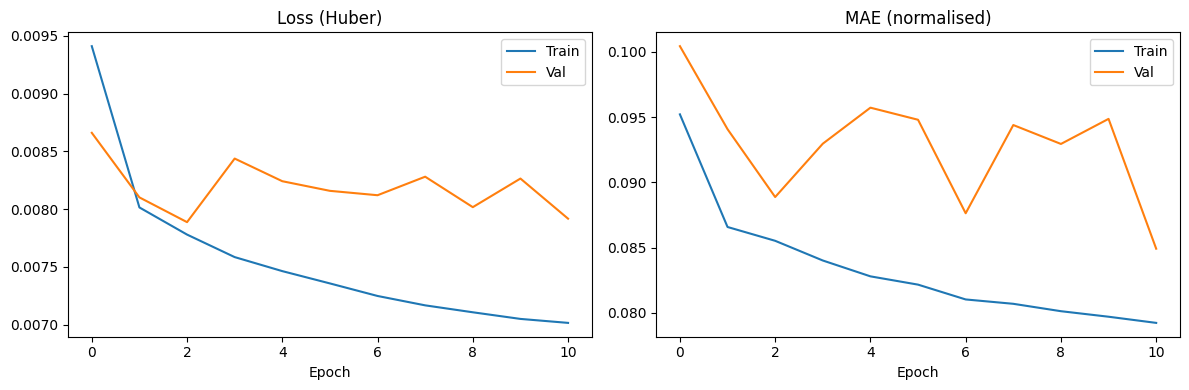

In [ ]:
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        f'{OUT_DIR}/lstm_best.keras',
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    [Xe_tr, Xd_tr], y_tr,
    validation_data=([Xe_va, Xd_va], y_va),
    epochs    = 60,
    batch_size= 64,
    callbacks = cb_list,
    verbose   = 1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (Huber)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE (normalised)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/training_curves.png', dpi=100)
plt.show()

#7. Evaluate on Hold-Out House (H02)

  LSTM Forecaster — H02 Test Results
  MAE  : 137.70 W
  RMSE : 200.17 W
  MAPE : 351585.81 %


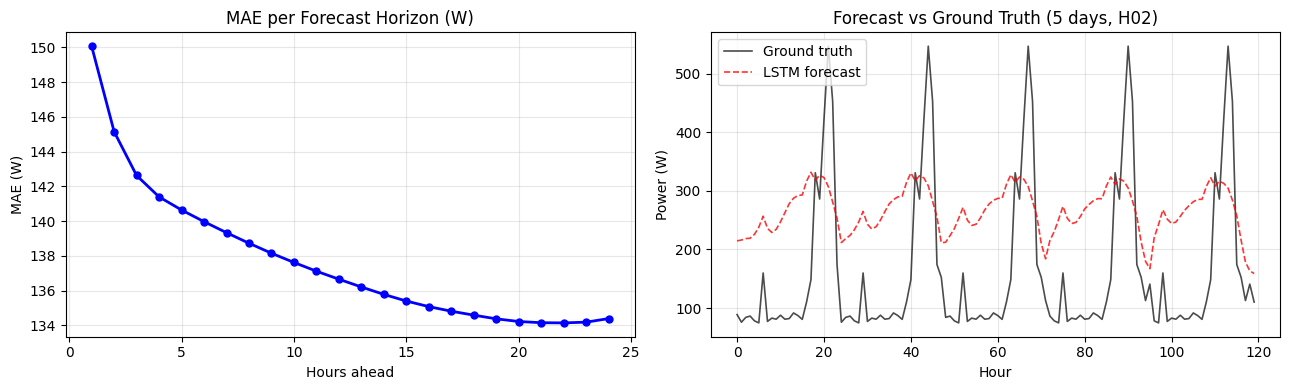

In [ ]:
# Predict on H02 test set
y_pred_norm = model.predict([Xe_te, Xd_te], batch_size=64, verbose=0)

# Denormalise → watts
y_pred_W = target_scaler.inverse_transform(
    y_pred_norm.reshape(-1, 1)
).reshape(y_pred_norm.shape)

y_true_W = target_scaler.inverse_transform(
    y_te.reshape(-1, 1)
).reshape(y_te.shape)

y_pred_W = np.clip(y_pred_W, 0, None)

# Flatten for global metrics
y_true_flat = y_true_W.flatten()
y_pred_flat = y_pred_W.flatten()

mae  = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mape = np.mean(np.abs((y_true_flat - y_pred_flat) /
               np.maximum(y_true_flat, 1e-3))) * 100

# Per-horizon metrics (how accuracy degrades over 24h)
mae_per_h = [mean_absolute_error(y_true_W[:, h, 0], y_pred_W[:, h, 0])
             for h in range(HORIZON)]

print('=' * 44)
print(f'  LSTM Forecaster — H02 Test Results')
print(f'  MAE  : {mae:.2f} W')
print(f'  RMSE : {rmse:.2f} W')
print(f'  MAPE : {mape:.2f} %')
print('=' * 44)

# Per-horizon plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, 25), mae_per_h, 'bo-', lw=2, ms=5)
axes[0].set_title('MAE per Forecast Horizon (W)')
axes[0].set_xlabel('Hours ahead')
axes[0].set_ylabel('MAE (W)')
axes[0].grid(alpha=0.3)

# Sample prediction vs ground truth (5 days)
N = 5
sample_true = y_true_W[:N].reshape(-1)
sample_pred = y_pred_W[:N].reshape(-1)
axes[1].plot(sample_true, 'k-', lw=1.2, alpha=0.7, label='Ground truth')
axes[1].plot(sample_pred, 'r--', lw=1.2, alpha=0.8, label='LSTM forecast')
axes[1].set_title(f'Forecast vs Ground Truth ({N} days, H02)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Power (W)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/forecast_evaluation.png', dpi=120)
plt.show()

#8. Integrate with Phase 1 Occupancy Simulation

In [ ]:
# Re-instantiate simulator from Phase 1
class OccupancySimulator:
    def __init__(self, delta_table, house_baseline=150.0, default_occupants=2):
        self.delta_table       = delta_table
        self.house_baseline    = house_baseline
        self.default_occupants = default_occupants

    def _get_delta(self, hour, is_weekend):
        row = self.delta_table[
            (self.delta_table.hour == hour) &
            (self.delta_table.is_weekend == int(is_weekend))
        ]
        return float(row['delta_W_mean'].values[0]) if len(row) else 0.0

    def _hvac(self, outdoor_temp):
        hvac = np.zeros(24)
        if outdoor_temp is None:
            return hvac
        if outdoor_temp < 15:
            load = (15 - outdoor_temp) * 12
            hvac[17:22] += load
            hvac[6:9]   += load * 0.5
        elif outdoor_temp > 25:
            load = (outdoor_temp - 25) * 8
            hvac[10:22] += load
        return hvac

    def adjust(self, lstm_forecast_24h, n_people=2, is_vacation=False,
               guests=0, is_weekend=False, outdoor_temp=None, solar_gen=None):
        base = np.array(lstm_forecast_24h, dtype=float)

        if is_vacation:
            occ_prob = np.zeros(24)
        else:
            total   = n_people + guests
            scale   = min(total / self.default_occupants, 2.5)
            base_p  = np.array([
                0.9,0.9,0.9,0.9,0.9,0.8,
                0.6,0.4,0.3,0.2,0.2,0.2,
                0.2,0.2,0.2,0.3,0.4,0.7,
                0.8,0.9,0.9,0.9,0.9,0.9,
            ])
            if is_weekend:
                base_p = np.clip(base_p * 1.3, 0, 1)
            occ_prob = np.clip(base_p * scale, 0, 1)

        occ_delta = np.array([
            self._get_delta(h, is_weekend) * occ_prob[h]
            for h in range(24)
        ])
        hvac       = self._hvac(outdoor_temp)
        gross      = np.clip(base + occ_delta + hvac, 0, None)
        solar      = np.array(solar_gen) if solar_gen is not None else np.zeros(24)
        net        = gross - solar

        return {
            'hour':        np.arange(24),
            'lstm_base':   base,
            'occ_delta':   occ_delta,
            'hvac':        hvac,
            'gross_load':  gross,
            'solar':       solar,
            'net_load':    net,
            'grid_import': np.maximum(net, 0),
            'grid_export': np.maximum(-net, 0),
            'occ_prob':    occ_prob,
        }


# Build simulator with H02 baseline
sim = OccupancySimulator(
    delta_table       = delta_table,
    house_baseline    = float(base_profiles['house_02'].mean()),
    default_occupants = 2
)

# Use one LSTM prediction as the base
sample_lstm_forecast = y_pred_W[10, :, 0]   # pick sample window #10
sample_true          = y_true_W[10, :, 0]

print(f'Sample LSTM forecast (mean): {sample_lstm_forecast.mean():.1f} W')
print(f'Sample ground truth  (mean): {sample_true.mean():.1f} W')

Sample LSTM forecast (mean): 241.4 W
Sample ground truth  (mean): 180.2 W


#9. Full What - If Scenario Comparision (LSTM + Simulator)

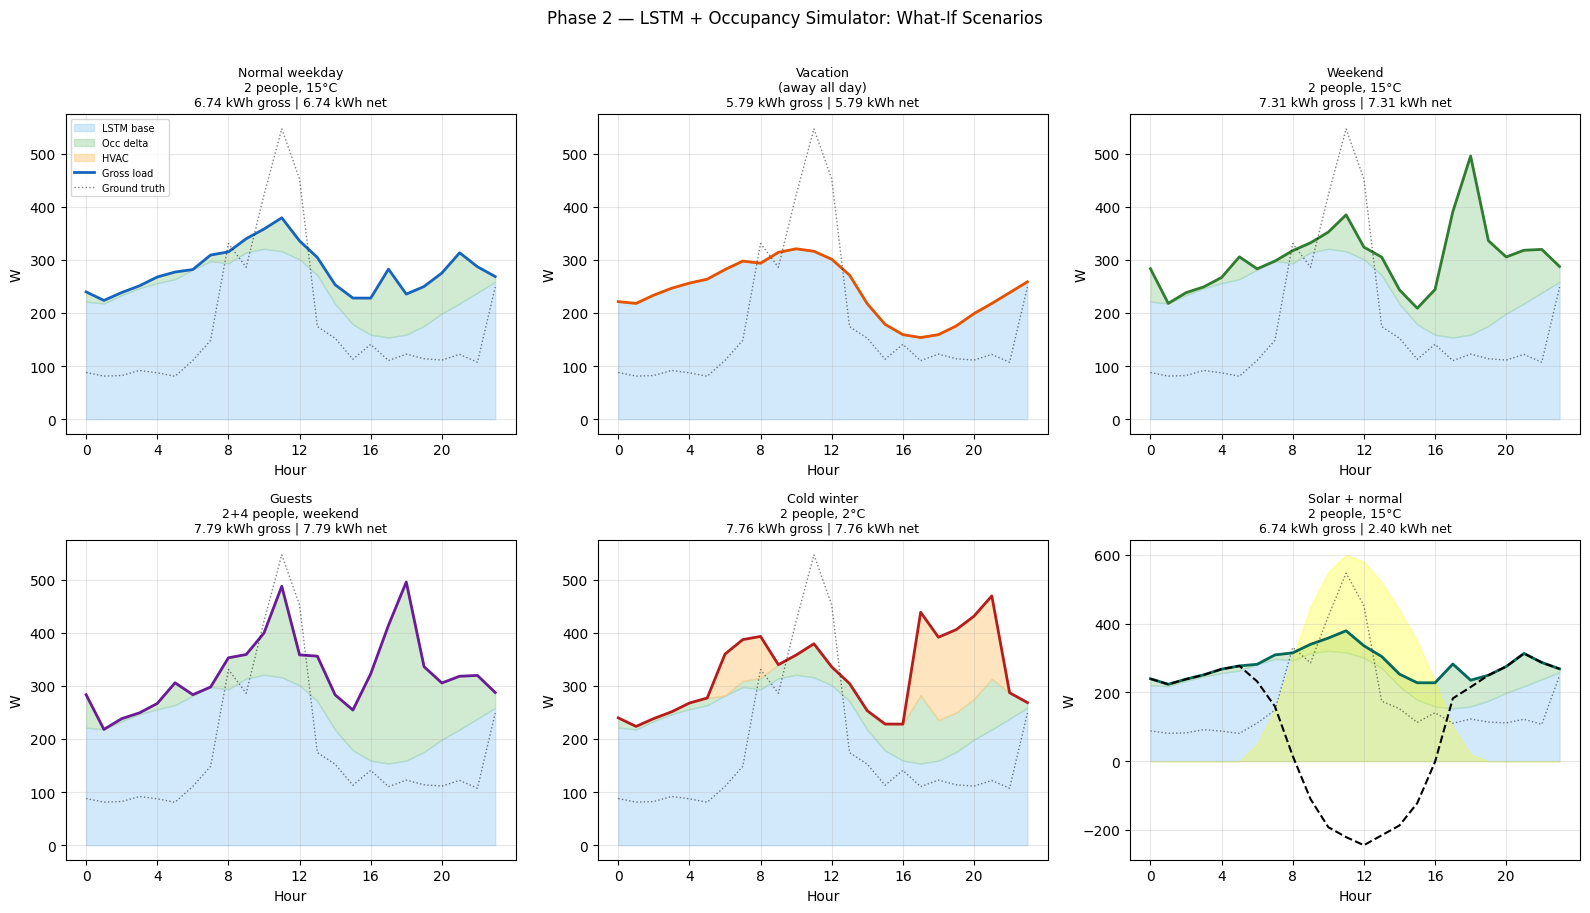


=== Scenario Summary ===
                     Scenario  Gross kWh  Net kWh  Peak W  Solar kWh  Export kWh
Normal weekday 2 people, 15°C      6.742    6.742   379.0       0.00       0.000
      Vacation (away all day)      5.793    5.793   321.0       0.00       0.000
       Weekend 2 people, 15°C      7.307    7.307   495.0       0.00       0.000
   Guests 2+4 people, weekend      7.792    7.792   495.0       0.00       0.000
    Cold winter 2 people, 2°C      7.756    7.756   469.0       0.00       0.000
Solar + normal 2 people, 15°C      6.742    2.402   379.0       4.34       1.294


In [ ]:
# Synthetic solar generation profile (pvlib-style, peaking at noon)
solar_profile = np.array([
    0,0,0,0,0,0,
    50,150,300,450,550,600,
    580,520,440,350,230,100,
    20,0,0,0,0,0
], dtype=float)   # W — replace with real pvlib output in Phase 3

scenarios = {
    'Normal weekday\n2 people, 15°C': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=False, outdoor_temp=15),

    'Vacation\n(away all day)': dict(
        n_people=2, is_vacation=True, guests=0,
        is_weekend=False, outdoor_temp=15),

    'Weekend\n2 people, 15°C': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=True, outdoor_temp=15),

    'Guests\n2+4 people, weekend': dict(
        n_people=2, is_vacation=False, guests=4,
        is_weekend=True, outdoor_temp=15),

    'Cold winter\n2 people, 2°C': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=False, outdoor_temp=2),

    'Solar + normal\n2 people, 15°C': dict(
        n_people=2, is_vacation=False, guests=0,
        is_weekend=False, outdoor_temp=15,
        solar_gen=solar_profile),
}

results = {}
for name, params in scenarios.items():
    results[name] = sim.adjust(sample_lstm_forecast, **params)

# 6-panel plot
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = ['#1565C0','#E65100','#2E7D32','#6A1B9A','#B71C1C','#00695C']

summary_rows = []
for ax, (name, res), col in zip(axes, results.items(), palette):
    h = res['hour']

    # Stacked fill: base → occ_delta → hvac
    base = res['lstm_base']
    top1 = base + res['occ_delta']
    top2 = top1 + res['hvac']

    ax.fill_between(h, 0,    base, alpha=0.4, color='#90CAF9', label='LSTM base')
    ax.fill_between(h, base, top1, alpha=0.5, color='#A5D6A7', label='Occ delta')
    ax.fill_between(h, top1, top2, alpha=0.5, color='#FFCC80', label='HVAC')
    ax.plot(h, res['gross_load'], color=col, lw=2, label='Gross load')

    if res['solar'].sum() > 0:
        ax.fill_between(h, 0, res['solar'], alpha=0.3,
                        color='yellow', label='Solar')
        ax.plot(h, res['net_load'], 'k--', lw=1.5, label='Net load')

    ax.plot(h, sample_true, 'k:', lw=1, alpha=0.5, label='Ground truth')

    kwh = res['gross_load'].sum() / 1000
    net_kwh = res['net_load'].sum() / 1000
    ax.set_title(f'{name}\n{kwh:.2f} kWh gross | {net_kwh:.2f} kWh net', fontsize=9)
    ax.set_xlabel('Hour')
    ax.set_ylabel('W')
    ax.set_xticks(range(0, 24, 4))
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=7, loc='upper left')

    summary_rows.append({
        'Scenario':   name.replace('\n', ' '),
        'Gross kWh':  round(kwh, 3),
        'Net kWh':    round(net_kwh, 3),
        'Peak W':     round(res['gross_load'].max(), 0),
        'Solar kWh':  round(res['solar'].sum() / 1000, 3),
        'Export kWh': round(res['grid_export'].sum() / 1000, 3),
    })

plt.suptitle('Phase 2 — LSTM + Occupancy Simulator: What-If Scenarios',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/scenarios_phase2.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
summary_df = pd.DataFrame(summary_rows)
print('\n=== Scenario Summary ===')
print(summary_df.to_string(index=False))

#10. Save All Phase 2 Artefacts

In [ ]:
import joblib

# Model already saved via ModelCheckpoint → lstm_best.keras
# Save scalers
joblib.dump(feat_scaler,   f'{OUT_DIR}/feat_scaler.pkl')
joblib.dump(target_scaler, f'{OUT_DIR}/target_scaler.pkl')

# Save feature column list
pd.Series(feature_cols).to_csv(f'{OUT_DIR}/feature_cols.csv', index=False)

# Save evaluation metrics
metrics = pd.DataFrame([{
    'MAE_W':  round(mae, 2),
    'RMSE_W': round(rmse, 2),
    'MAPE_%': round(mape, 2),
    'lookback_h': LOOKBACK,
    'horizon_h':  HORIZON,
    'train_house': '01',
    'test_house':  '02',
}])
metrics.to_csv(f'{OUT_DIR}/evaluation_metrics.csv', index=False)

# Save scenario summary
summary_df.to_csv(f'{OUT_DIR}/scenario_summary.csv', index=False)

# Per-horizon MAE
pd.DataFrame({'horizon_h': range(1,25), 'MAE_W': mae_per_h}).to_csv(
    f'{OUT_DIR}/per_horizon_mae.csv', index=False
)

print('Phase 2 artefacts saved to:', OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(f'{OUT_DIR}/{f}')
    print(f'  {f:<35} {sz/1024:>6.0f} KB')

print('\n✓ Phase 2 complete.')
print('→ Next: Phase 3 — Solar PV forecasting (pvlib + ERA5 weather)')

Phase 2 artefacts saved to: /content/drive/MyDrive/phase2_outputs
  evaluation_metrics.csv                   0 KB
  feat_scaler.pkl                          2 KB
  feature_cols.csv                         0 KB
  forecast_evaluation.png                 92 KB
  lstm_best.keras                       3522 KB
  per_horizon_mae.csv                      1 KB
  scenario_summary.csv                     0 KB
  scenarios_phase2.png                   257 KB
  target_scaler.pkl                        1 KB
  training_curves.png                     53 KB

✓ Phase 2 complete.
→ Next: Phase 3 — Solar PV forecasting (pvlib + ERA5 weather)
